In [12]:
import os

os.environ["CC"] = "/usr/bin/gcc"
os.environ["CXX"] = "/usr/bin/g++"

import cmdstanpy
cmdstanpy.install_cmdstan(verbose=True)

CmdStan install directory: /u/zwu1/.cmdstan
CmdStan version 2.38.0 already installed
Test model compilation

--- Translating Stan model to C++ code ---
bin/stanc  --o=examples/bernoulli/bernoulli.hpp examples/bernoulli/bernoulli.stan

--- Compiling C++ code ---
/usr/bin/g++ -std=c++17 -pthread -D_REENTRANT -Wno-sign-compare -Wno-ignored-attributes -Wno-class-memaccess      -I stan/lib/stan_math/lib/tbb_2020.3/include    -O3 -I src -I stan/src -I stan/lib/rapidjson_1.1.0/ -I lib/CLI11-1.9.1/ -I stan/lib/stan_math/ -I stan/lib/stan_math/lib/eigen_3.4.0 -I stan/lib/stan_math/lib/boost_1.87.0 -I stan/lib/stan_math/lib/sundials_6.1.1/include -I stan/lib/stan_math/lib/sundials_6.1.1/src/sundials    -DBOOST_DISABLE_ASSERTS          -c -Wno-ignored-attributes   -x c++ -o examples/bernoulli/bernoulli.o examples/bernoulli/bernoulli.hpp

--- Linking model ---
/usr/bin/g++ -std=c++17 -pthread -D_REENTRANT -Wno-sign-compare -Wno-ignored-attributes -Wno-class-memaccess      -I stan/lib/stan_math/lib

True

In [13]:
import numpy as np
import pandas as pd
from scipy.linalg import expm
from scipy.stats import norm
import os

# Set seed for reproducibility
np.random.seed(123)

############################################################
# 1. Unified Simulation Function (Aligned with Stan Model)
############################################################

# def simulate_study(shifted_mean=False, Nsub=600, p=2, q=2):
#     """
#     Simulates longitudinal IRT data with a latent SDE process.
#     Matches the 'Steady-State' logic in the provided Stan code.
#     """
#     K, R = 7, 2
#     repme = np.random.randint(2, 13, size=Nsub)
#     N = np.sum(repme)
    
#     # 1-based indexing for Stan compatibility
#     ID = np.repeat(np.arange(1, Nsub + 1), repme)
#     cumu = np.cumsum(repme)
    
#     # Covariates
#     X = np.random.normal(size=(N, p))
#     Z = np.random.binomial(1, 0.5, size=(N, q)) 
    
#     # Latent Process Parameters
#     Gamma = np.array([[0.18, -0.07], [0.10, 0.15]])
#     rho = 0.6
#     Omega = np.array([[1.0, rho], [rho, 1.0]])
    
#     gamma_latent = np.zeros((R, q))
#     if shifted_mean:
#         gamma_latent = np.array([[0.8, 1.2], [0.5, 0.9]])

#     xi = np.zeros((N, R))
#     deltat = np.zeros(N)
#     time = np.zeros(N)
    
#     # --- 1. Latent Trajectories (SDE) ---
#     for i in range(Nsub):
#         start = cumu[i] - repme[i]
#         # Irregular time points
#         t_subj = np.concatenate(([0], np.cumsum(np.random.uniform(0.5, 1.5, size=repme[i]-1))))
#         time[start : start + repme[i]] = t_subj
        
#         # Initial State: mu_start = gamma_latent * Z[start]' * time[start]
#         mu_start = (gamma_latent @ Z[start]) * time[start]
#         xi[start] = np.random.multivariate_normal(mu_start, Omega)
        
#         for j in range(1, repme[i]):
#             k = start + j
#             dt = t_subj[j] - t_subj[j-1]
#             deltat[k] = dt
            
#             Phi = expm(-dt * Gamma)
#             # Q = Omega - Phi * Omega * Phi'
#             Q = Omega - Phi @ Omega @ Phi.T
            
#             target_k = (gamma_latent @ Z[k]) * time[k]
#             target_prev = (gamma_latent @ Z[k-1]) * time[k-1]
#             cond_mean = target_k + Phi @ (xi[k-1] - target_prev)
            
#             xi[k] = np.random.multivariate_normal(cond_mean, Q + np.eye(R)*1e-9)

#     # --- 2. Measurement Model (IRT) ---
#     lambda_param = np.random.uniform(0.7, 1.3, size=K)
#     beta = np.random.normal(size=(K, p))
#     # Random effects for local dependence
#     sigma_bk = np.random.uniform(0.3, 0.6, size=K)
#     b_raw = np.random.normal(0, 1, size=(Nsub, K))
#     b = b_raw * sigma_bk 
    
#     Y = np.zeros((N, K), dtype=int)
    
#     for i in range(N):
#         sub_idx = ID[i] - 1
#         for k in range(K):
#             f_idx = 0 if k < 3 else 1
#             # Linear Predictor (Eta)
#             eta = X[i] @ beta[k] + lambda_param[k] * xi[i, f_idx] + b[sub_idx, k]
            
#             def inv_logit(x): return 1 / (1 + np.exp(-x))

#             if k < 3: # Binary Items (Items 1-3)
#                 theta = -0.5 # Baseline intercept
#                 prob = inv_logit(theta + eta)
#                 Y[i, k] = np.random.binomial(1, prob)
#             else: # Ordinal Items (Items 4-7, 3 categories)
#                 thresholds = np.sort(np.random.normal(0, 1, size=2))
#                 # Prob(Y <= m) = inv_logit(theta[m] - eta)
#                 p1 = inv_logit(thresholds[0] - eta)
#                 p2 = inv_logit(thresholds[1] - eta) - p1
#                 p3 = 1 - inv_logit(thresholds[1] - eta)
#                 Y[i, k] = np.random.choice([1, 2, 3], p=[max(0, p1), max(0, p2), max(0, p3)])

#     return {
#         'N': N, 'Nsub': Nsub, 'K': K, 'R': R, 'p': p, 'q': q,
#         'ID': ID, 'cumu': cumu, 'repme': repme, 'Y': Y,
#         'missing_ID': np.zeros((N, K), dtype=int),
#         'deltat': deltat, 'time': time, 'X': X, 'Z': Z,
#         'ncate4': 3, 'ncate5': 3, 'ncate6': 3, 'ncate7': 3,
#         'true_xi': xi, 'true_gamma': gamma_latent, 
#         'true_lambda': lambda_param, 'true_Gamma_mat': Gamma
#     }


def simulate_study(shifted_mean=False, Nsub=600, p=2, q=2):
    """
    Simulates longitudinal IRT data.
    Binary items (1-3) -> 0/1 for bernoulli_logit.
    Ordinal items (4-7) -> 1+ for ordered_logistic.
    """
    K, R = 7, 2
    repme = np.random.randint(2, 13, size=Nsub)
    N = np.sum(repme)
    
    ID = np.repeat(np.arange(1, Nsub + 1), repme)
    cumu = np.cumsum(repme)
    
    # Covariates
    X = np.random.normal(size=(N, p))
    Z = np.random.binomial(1, 0.5, size=(N, q)) 
    
    # --- 1. Latent Process Parameters ---
    Gamma = np.array([[0.18, -0.07], 
                      [0.10, 0.15]])
    rho = 0.60
    Omega = np.array([[1.0, rho], [rho, 1.0]])
    
    gamma_latent = np.zeros((R, q))
    if shifted_mean:
        gamma_latent = np.array([[0.8, 1.2], [0.5, 0.9]])

    xi = np.zeros((N, R))
    deltat = np.zeros(N)
    time = np.zeros(N)
    
    for i in range(Nsub):
        start = cumu[i] - repme[i]
        t_subj = np.concatenate(([0], np.cumsum(np.random.uniform(0.5, 1.5, size=repme[i]-1))))
        time[start : start + repme[i]] = t_subj
        
        mu_start = (gamma_latent @ Z[start]) * time[start]
        xi[start] = np.random.multivariate_normal(mu_start, Omega)
        
        for j in range(1, repme[i]):
            k = start + j
            dt = t_subj[j] - t_subj[j-1]
            deltat[k] = dt
            Phi = expm(-dt * Gamma)
            Q = Omega - Phi @ Omega @ Phi.T
            
            target_k = (gamma_latent @ Z[k]) * time[k]
            target_prev = (gamma_latent @ Z[k-1]) * time[k-1]
            cond_mean = target_k + Phi @ (xi[k-1] - target_prev)
            # Add jitter in simulation for parity with Stan stability
            xi[k] = np.random.multivariate_normal(cond_mean, Q + np.eye(R)*1e-9)

    # --- 2. Measurement Model Parameters ---
    lam = np.zeros(K)
    lam[0], lam[1], lam[2] = 1.20, 4.00, 4.10  
    lam[3], lam[4], lam[5], lam[6] = 3.10, 5.20, 3.00, 1.70 

    B = np.zeros((K, p))
    B[1, :] = [0.10, 0.20]   
    B[4, :] = [0.30, -0.30]  

    sig_b = np.zeros(K)
    sig_b[0], sig_b[2], sig_b[3], sig_b[6] = 3.70, 4.80, 3.10, 1.70
    b = np.random.normal(0, 1, size=(Nsub, K)) * sig_b
    
    Y = np.zeros((N, K), dtype=int)
    def inv_logit(x): return 1 / (1 + np.exp(-x))

    for i in range(N):
        sub_idx = ID[i] - 1
        for k in range(K):
            f_idx = 0 if k < 3 else 1
            eta = X[i] @ B[k] + lam[k] * xi[i, f_idx] + b[sub_idx, k]

            # BINARY ITEMS (1, 2, 3) -> Must be 0 or 1
            if k < 3:
                # Map theta values from table for binary intercepts if provided
                # Else use 0.0 or a custom baseline
                theta_base = 0.0 
                if k == 0: theta_base = 2.30 # Using first theta1 from table
                
                prob = inv_logit(theta_base + eta)
                Y[i, k] = np.random.binomial(1, prob)

            # ORDINAL ITEMS (4, 5, 6, 7) -> Must be 1, 2, 3...
            else:
                if k == 4: # Item 5 (theta_51, 52, 53)
                    th = [-7.50, -2.50, 2.60]
                elif k == 6: # Item 7 (theta_71, 72, 73)
                    th = [-4.30, -1.00, 1.40]
                else: # Items 4 and 6 (binary logic but in ordered_logistic)
                    th = [0.0]

                p_cum = [inv_logit(t - eta) for t in th]
                probs = np.diff([0] + p_cum + [1])
                # Shift to 1-based indexing for ordered_logistic
                Y[i, k] = np.random.choice(np.arange(1, len(probs) + 1), 
                                           p=np.clip(probs, 0, 1) / np.sum(probs))

    return {
        'N': N, 'Nsub': Nsub, 'K': K, 'R': R, 'p': p, 'q': q,
        'ID': ID, 'cumu': cumu, 'repme': repme, 'Y': Y,
        'missing_ID': np.zeros((N, K), dtype=int),
        'deltat': deltat, 'time': time, 'X': X, 'Z': Z,
        'ncate4': 2, 'ncate5': 4, 'ncate6': 2, 'ncate7': 4, 
        'true_xi': xi, 'true_gamma': gamma_latent, 
        'true_lambda': lam, 'true_Gamma_mat': Gamma
    }

############################################################
# 2. Execution and Results Helpers
############################################################

def calculate_latent_rmse(fit, true_xi):
    xi_samples = fit.stan_variable("xi") # [draws, N, R]
    xi_est_mean = np.mean(xi_samples, axis=0)
    return np.sqrt(np.mean((true_xi - xi_est_mean)**2))

def get_detailed_table(fit, data_obj, label):
    # Map ground truths to flat arrays for comparison
    true_vals = {
        'lambda': data_obj['true_lambda'],
        'gamma_latent': data_obj['true_gamma'].flatten(order='F'),
        'Gamma': data_obj['true_Gamma_mat'].flatten(order='F')
    }
    
    summ = fit.summary()
    res_list = []
    
    for par, truth_vec in true_vals.items():
        # Find parameters in Stan output starting with the name
        pattern = f"^{par}(\\[|$)"
        matches = summ[summ.index.str.contains(pattern, regex=True)]
        
        for i, (idx, row) in enumerate(matches.head(len(truth_vec)).iterrows()):
            truth = truth_vec[i]
            bias = row['Mean'] - truth
            res_list.append({
                'Comparison': label, 'Parameter': idx,
                'Truth': round(truth, 3), 'Est': round(row['Mean'], 3),
                'Bias': round(bias, 3), 'Rhat': round(row['R_hat'], 3)
            })
    return pd.DataFrame(res_list)

############################################################
# 3. Main Running Block
############################################################

# # 1. Generate Datasets
# d1 = simulate_study(shifted_mean=False)
# d2 = simulate_study(shifted_mean=True)

# # 2. Setup Models (Assuming files exist in current directory)
# mod_fix = cmdstanpy.CmdStanModel(stan_file="model_fix_mean.stan")
# mod_shift = cmdstanpy.CmdStanModel(stan_file="model_shift_mean.stan")

# # 3. Sampling (Example call for one cell)
# fit11 = mod_fix.sample(data=d1, chains=5, inits=0.5, iter_warmup=10000, iter_sampling=10000, show_progress=True)
# # 4. Final Aggregation Example
# table11 = get_detailed_table(fit11, d1, "Std_Fix")
# print(table11)

# fit12 = mod_shift.sample(data=d1, chains=5, inits=0.5, iter_warmup=10000, iter_sampling=10000, show_progress=True)
# table12 = get_detailed_table(fit12, d1, "Std_Shift")
# print(table12)

# fit21 = mod_fix.sample(data=d2, chains=5, inits=0.5, iter_warmup=10000, iter_sampling=10000, show_progress=True)
# table21 = get_detailed_table(fit21, d2, "Shift_Fix")
# print(table21)

# fit22 = mod_shift.sample(data=d2, chains=5, inits=0.5, iter_warmup=10000, iter_sampling=10000, show_progress=True)
# table22 = get_detailed_table(fit22, d2, "Shift_Shift")
# print(table22)

In [14]:
import concurrent.futures

# 1. Define a helper function for the worker processes
def run_scenario(model, data, label):
    print(f"Starting: {label}")
    fit = model.sample(
        data=data, 
        chains=3, 
        inits=0.5, 
        iter_warmup=3000, 
        iter_sampling=3000, 
        show_progress=False # Set to False to avoid garbled console output
    )
    return fit, get_detailed_table(fit, data, label)

# 2. Setup (as before)
d1 = simulate_study(shifted_mean=False)
d2 = simulate_study(shifted_mean=True)
mod_fix = cmdstanpy.CmdStanModel(stan_file="model_fix_mean.stan")
mod_shift = cmdstanpy.CmdStanModel(stan_file="model_shift_mean.stan")

# 3. Define the scenarios to run
scenarios = [
    (mod_fix, d1, "Std_Fix"),
    (mod_shift, d1, "Std_Shift"),
    (mod_fix, d2, "Shift_Fix"),
    (mod_shift, d2, "Shift_Shift")
]

# 4. Execute in Parallel
results = []
with concurrent.futures.ProcessPoolExecutor(max_workers=4) as executor:
    # Map the scenarios to the worker function
    futures = [executor.submit(run_scenario, *s) for s in scenarios]
    
    for future in concurrent.futures.as_completed(futures):
        results.append(future.result())

# 5. Print results
fits = []
for fit, table in results:
    print(table)
    fits.append(fit)

05:39:10 - cmdstanpy - INFO - compiling stan file /nfs/nfs9/home/nobackup/zwu1/gnpc_explor/src/model_fix_mean.stan to exe file /nfs/nfs9/home/nobackup/zwu1/gnpc_explor/src/model_fix_mean
05:40:11 - cmdstanpy - INFO - compiled model executable: /nfs/nfs9/home/nobackup/zwu1/gnpc_explor/src/model_fix_mean
05:40:11 - cmdstanpy - INFO - compiling stan file /nfs/nfs9/home/nobackup/zwu1/gnpc_explor/src/model_shift_mean.stan to exe file /nfs/nfs9/home/nobackup/zwu1/gnpc_explor/src/model_shift_mean
05:41:14 - cmdstanpy - INFO - compiled model executable: /nfs/nfs9/home/nobackup/zwu1/gnpc_explor/src/model_shift_mean


Starting: Std_Fix
Starting: Std_Shift
Starting: Shift_Fix
Starting: Shift_Shift


05:41:14 - cmdstanpy - INFO - CmdStan start processing
05:41:14 - cmdstanpy - INFO - CmdStan start processing
05:41:14 - cmdstanpy - INFO - Chain [1] start processing
05:41:14 - cmdstanpy - INFO - Chain [2] start processing
05:41:14 - cmdstanpy - INFO - Chain [1] start processing
05:41:14 - cmdstanpy - INFO - Chain [2] start processing
05:41:14 - cmdstanpy - INFO - Chain [3] start processing
05:41:14 - cmdstanpy - INFO - Chain [3] start processing
05:41:14 - cmdstanpy - INFO - CmdStan start processing
05:41:14 - cmdstanpy - INFO - CmdStan start processing
05:41:14 - cmdstanpy - INFO - Chain [1] start processing
05:41:14 - cmdstanpy - INFO - Chain [2] start processing
05:41:14 - cmdstanpy - INFO - Chain [1] start processing
05:41:14 - cmdstanpy - INFO - Chain [2] start processing
05:41:14 - cmdstanpy - INFO - Chain [3] start processing
05:41:14 - cmdstanpy - INFO - Chain [3] start processing
12:33:29 - cmdstanpy - INFO - Chain [1] done processing
13:06:12 - cmdstanpy - INFO - Chain [2] 

   Comparison          Parameter  Truth    Est   Bias   Rhat
0   Std_Shift          lambda[1]   1.20  1.005 -0.195  1.001
1   Std_Shift          lambda[2]   4.00  4.160  0.160  1.002
2   Std_Shift          lambda[3]   4.10  4.276  0.176  1.003
3   Std_Shift          lambda[4]   3.10  3.251  0.151  1.001
4   Std_Shift          lambda[5]   5.20  5.138 -0.062  1.006
5   Std_Shift          lambda[6]   3.00  2.883 -0.117  1.002
6   Std_Shift          lambda[7]   1.70  1.678 -0.022  1.001
7   Std_Shift  gamma_latent[1,1]   0.00 -0.005 -0.005  1.000
8   Std_Shift  gamma_latent[1,2]   0.00  0.003  0.003  1.001
9   Std_Shift  gamma_latent[2,1]   0.00 -0.002 -0.002  1.001
10  Std_Shift  gamma_latent[2,2]   0.00 -0.002 -0.002  1.000
11  Std_Shift         Gamma[1,1]   0.18  0.197  0.017  1.013
12  Std_Shift         Gamma[1,2]   0.10 -0.069 -0.169  1.010
13  Std_Shift         Gamma[2,1]  -0.07  0.098  0.168  1.002
14  Std_Shift         Gamma[2,2]   0.15  0.155  0.005  1.001
   Comparison   Paramete

In [15]:
############################################################
# Posterior statistics extraction
############################################################

def extract_param_stats(fit, param_name):

    summ = fit.summary()

    rows = summ[summ.index.str.startswith(param_name)]

    if rows.shape[0] == 0:
        return None

    cols = rows.columns

    sd_col = "SD" if "SD" in cols else "StdDev"
    ess_col = "ESS_bulk" if "ESS_bulk" in cols else "N_Eff"

    if "2.5%" in cols:
        lower_col, upper_col = "2.5%", "97.5%"
    else:
        lower_col, upper_col = "5%", "95%"

    stats = {
        "mean": rows["Mean"].values,
        "sd": rows[sd_col].values,
        "ess": rows[ess_col].values,
        "rhat": rows["R_hat"].values,
        "lower": rows[lower_col].values,
        "upper": rows[upper_col].values
    }

    return stats



############################################################
# Metrics computation
############################################################

def compute_metrics(true_vals, stats):

    mean = stats["mean"]
    sd = stats["sd"]
    lower = stats["lower"]
    upper = stats["upper"]

    n = min(len(true_vals), len(mean))

    true_vals = true_vals[:n]
    mean = mean[:n]
    sd = sd[:n]

    bias = mean - true_vals
    rel_bias = bias / (np.abs(true_vals) + 1e-9)
    mse = bias**2 + sd**2
    coverage = ((true_vals >= lower[:n]) & (true_vals <= upper[:n])).astype(int)

    df = pd.DataFrame({
        "Truth": true_vals,
        "Estimate": mean,
        "Bias": bias,
        "RelativeBias": rel_bias,
        "MSE": mse,
        "Coverage": coverage,
        "ESS": stats["ess"][:n],
        "Rhat": stats["rhat"][:n]
    })

    return df



def get_truth_dict(data_obj):

    truth = {
        "lambda": data_obj['true_lambda'],
        "Gamma": data_obj['true_Gamma_mat'].flatten(order="F")
    }

    if np.any(data_obj['true_gamma'] != 0):
        truth["gamma_latent"] = data_obj['true_gamma'].flatten(order="F")

    return truth

############################################################
# Detailed comparison table
############################################################

def build_comparison_table(fit, data_obj, dataset_label, model_label):

    tables = []

    truth_dict = get_truth_dict(data_obj)

    for param, truth in truth_dict.items():

        stats = extract_param_stats(fit, param)

        if stats is None:
            print(f"{param} not in model {model_label}")
            continue

        df = compute_metrics(truth, stats)

        df["Parameter"] = [f"{param}_{i+1}" for i in range(len(df))]
        df["Dataset"] = dataset_label
        df["Model"] = model_label

        tables.append(df)

    return pd.concat(tables)


import arviz as az
import matplotlib.pyplot as plt

def trace_plots(fit, save_prefix):

    idata = az.from_cmdstanpy(posterior=fit)

    az.plot_trace(idata)
    plt.savefig(f"{save_prefix}_trace.png", dpi=200)


import seaborn as sns
import matplotlib.pyplot as plt

def plot_posterior_vs_truth(table):

    plt.figure(figsize=(8,6))

    sns.scatterplot(
        data=table,
        x="Truth",
        y="Estimate",
        hue="Model",
        style="Dataset"
    )

    lims = [
        min(table["Truth"].min(), table["Estimate"].min()),
        max(table["Truth"].max(), table["Estimate"].max())
    ]

    plt.plot(lims, lims, '--k')
    plt.xlabel("True value")
    plt.ylabel("Posterior mean")
    plt.title("Posterior Estimates vs Truth")

    plt.show()


def latent_recovery_plot(fit, true_xi):

    xi_samples = fit.stan_variable("xi")
    xi_est = xi_samples.mean(axis=0)

    plt.scatter(true_xi.flatten(), xi_est.flatten(), alpha=0.3)
    plt.plot([-4,4],[-4,4],'r--')

    plt.xlabel("True latent")
    plt.ylabel("Estimated latent")

    plt.title("Latent recovery")

    plt.show()

In [16]:
results = []

# fits = [fit11, fit12, fit21, fit22]
datas = [d1, d1, d2, d2]
dlabs = ["Std","Std","Shift","Shift"]
mlabs = ["Fix","Shift","Fix","Shift"]

for fit, data, dlab, mlab in zip(fits, datas, dlabs, mlabs):

    table = build_comparison_table(fit, data, dlab, mlab)

    results.append(table)

final_table = pd.concat(results)

gamma_latent not in model Shift


In [17]:
summary_table = (
    final_table
    .groupby(["Dataset","Model","Parameter"])
    .agg({
        "Bias":"mean",
        "RelativeBias":"mean",
        "MSE":"mean",
        "Coverage":"mean",
        "ESS":"mean",
        "Rhat":"mean"
    })
    .reset_index()
)

print(summary_table)

   Dataset  Model       Parameter      Bias  RelativeBias        MSE  \
0    Shift    Fix         Gamma_1  0.052921      0.294006   0.004283   
1    Shift    Fix         Gamma_2 -0.165119     -1.651185   0.028352   
2    Shift    Fix         Gamma_3  0.220979      3.156843   0.049613   
3    Shift    Fix         Gamma_4 -0.046066     -0.307107   0.002783   
4    Shift    Fix  gamma_latent_1 -0.004930     -0.006162   0.001605   
5    Shift    Fix  gamma_latent_2  0.625650      1.251300   0.395146   
6    Shift    Fix  gamma_latent_3 -0.737447     -0.614539   0.544088   
7    Shift    Fix  gamma_latent_4 -0.024995     -0.027772   0.001677   
8    Shift    Fix        lambda_1 -0.025440     -0.021200   0.009621   
9    Shift    Fix        lambda_2  0.627580      0.156895   0.762268   
10   Shift    Fix        lambda_3  0.534630      0.130398   0.724257   
11   Shift    Fix        lambda_4  0.314460      0.101439   0.170484   
12   Shift    Fix        lambda_5  0.224400      0.043154   0.21

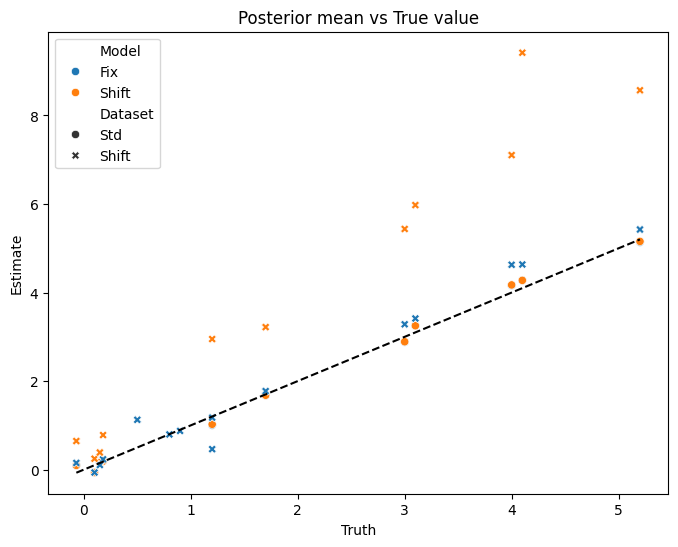

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=final_table,
    x="Truth",
    y="Estimate",
    hue="Model",
    style="Dataset"
)

lims = [
    final_table["Truth"].min(),
    final_table["Truth"].max()
]

plt.plot(lims, lims, "--k")

plt.title("Posterior mean vs True value")
plt.show()

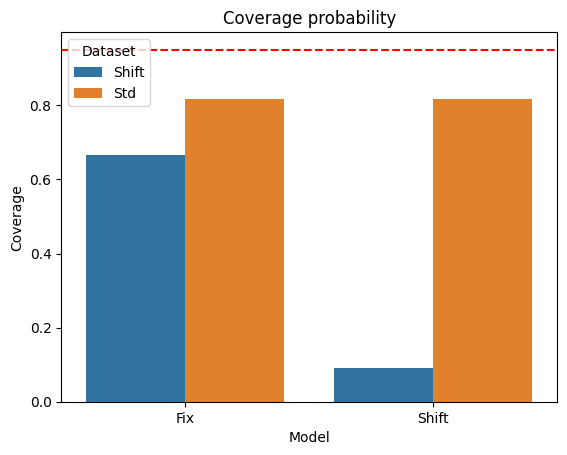

In [19]:
coverage = (
    final_table
    .groupby(["Dataset","Model"])["Coverage"]
    .mean()
    .reset_index()
)

sns.barplot(data=coverage, x="Model", y="Coverage", hue="Dataset")

plt.axhline(0.95, linestyle="--", color="red")

plt.title("Coverage probability")
plt.show()

array([[<Axes: title={'center': 'lambda'}>,
        <Axes: title={'center': 'lambda'}>]], dtype=object)

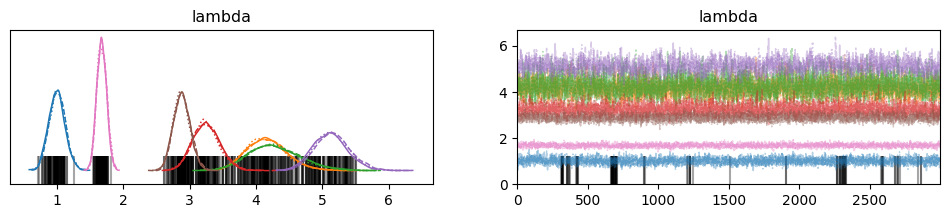

In [20]:
import arviz as az

idata = az.from_cmdstanpy(posterior=fits[0])

az.plot_trace(idata, var_names=["lambda"])

In [21]:
final_table.to_csv("parameter_results.csv", index=False)
summary_table.to_csv("summary_results.csv", index=False)